# **RNNs,LSTMs,GRU**

In [1]:
#imports
!pip install datasets -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Load IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")
train_data = dataset['train']
test_data = dataset['test']

# Split training data into train + validation
train_val_split = train_data.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split['train']
val_data = train_val_split['test']

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

# Simple tokenizer: lowercase + split on non-alphanumeric characters
def tokenizer(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

# Build vocabulary from training data
counter = Counter() #keeping track of which words appear most frequently
for example in train_data:
    counter.update(tokenizer(example['text']))

MAX_VOCAB = 20000
most_common = counter.most_common(MAX_VOCAB) #only getting the 20,000 most frequently occurring words.

# Reserve index 0 for <pad>, index 1 for <unk>
vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 22500
Validation size: 2500
Test size: 25000


In [3]:
#Pipelines to convert raw text/label → numbers
def text_pipeline(text):
    tokens = tokenizer(text)
    return [vocab.get(token, UNK_IDX) for token in tokens]

def label_pipeline(label):
    return float(label)  # dataset already has 0 = neg, 1 = pos

In [4]:
#Collate function — assembling a batch
def collate_batch(batch):
    labels, texts, lengths = [], [], []
    for example in batch:
        labels.append(label_pipeline(example['label']))
        ids = text_pipeline(example['text'])[:400]
        texts.append(torch.tensor(ids, dtype=torch.long))
        lengths.append(len(ids))
    labels = torch.tensor(labels, dtype=torch.float32)
    lengths = torch.tensor(lengths, dtype=torch.long)
    texts = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts.to(device), lengths, labels.to(device)

In [5]:
#dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, collate_fn=collate_batch)

In [6]:
#defining the model:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        hidden = self.dropout(hidden.squeeze(0))   #dropout applied here
        out = self.fc(hidden)
        return out.squeeze(1)

In [11]:
model = LSTMSentiment(len(vocab), pad_idx=PAD_IDX).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

In [8]:
#training and evaluation loops
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, lengths, labels in loader:
        optimizer.zero_grad()
        preds = model(texts, lengths)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
        correct += ((torch.sigmoid(preds) > 0.5).float() == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for texts, lengths, labels in loader:
            preds = model(texts, lengths)
            loss = criterion(preds, labels)
            total_loss += loss.item()
            correct += ((torch.sigmoid(preds) > 0.5).float() == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

In [12]:
#Running it
best_val_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(15):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')  # save best weights
        print(f"  ↳ New best model saved (val_acc={val_acc:.4f})")

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, lr={current_lr:.6f}")

# Load the best checkpoint before final testing
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc = evaluate(model, test_loader)
print(f"Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc:.4f}")

  ↳ New best model saved (val_acc=0.6900)
Epoch 1: train_loss=0.6374, train_acc=0.6233, val_loss=0.5827, val_acc=0.6900, lr=0.000500
  ↳ New best model saved (val_acc=0.7700)
Epoch 2: train_loss=0.5048, train_acc=0.7632, val_loss=0.5052, val_acc=0.7700, lr=0.000500
  ↳ New best model saved (val_acc=0.7780)
Epoch 3: train_loss=0.4202, train_acc=0.8149, val_loss=0.4546, val_acc=0.7780, lr=0.000500
  ↳ New best model saved (val_acc=0.8372)
Epoch 4: train_loss=0.3390, train_acc=0.8594, val_loss=0.3786, val_acc=0.8372, lr=0.000500
Epoch 5: train_loss=0.2923, train_acc=0.8839, val_loss=0.3690, val_acc=0.8352, lr=0.000500
  ↳ New best model saved (val_acc=0.8540)
Epoch 6: train_loss=0.2608, train_acc=0.8988, val_loss=0.3481, val_acc=0.8540, lr=0.000500
  ↳ New best model saved (val_acc=0.8612)
Epoch 7: train_loss=0.2205, train_acc=0.9180, val_loss=0.3378, val_acc=0.8612, lr=0.000500
  ↳ New best model saved (val_acc=0.8732)
Epoch 8: train_loss=0.1836, train_acc=0.9332, val_loss=0.3506, val_ac

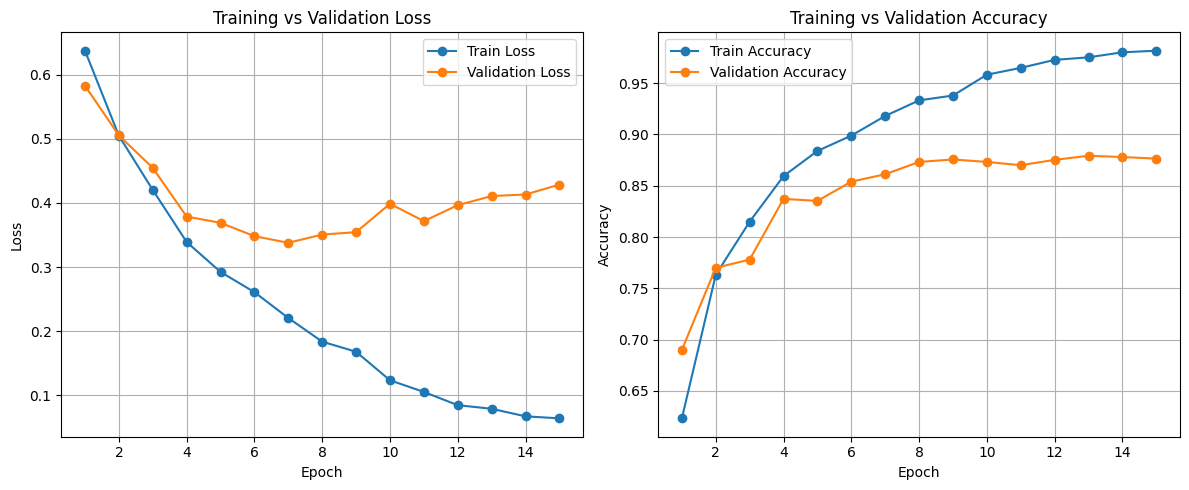

In [13]:
#plotting loss and accuracy
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **Summary of Results and Improvements — LSTM Sentiment Analysis (IMDB)**

The final model is a single-layer LSTM with learned 128-dimensional word embeddings, a 128-dimensional hidden state, dropout (0.3), and weight decay (1e-5), achieving 86.65% test accuracy with a test loss of 0.4584.

The model initially remained near chance-level accuracy (~50–55%) because padded tokens were being processed as real input, affecting the final hidden state used for classification. This was fixed using pack_padded_sequence, allowing the LSTM to process only the actual tokens in each review and raising accuracy to around 85%.

Gradient clipping and a ReduceLROnPlateau scheduler were added to stabilize training. Overfitting appeared after around epochs 6–7, with training accuracy approaching 99% while validation performance plateaued. Dropout, weight decay, and best-model checkpointing were used to reduce its impact.

Finally, lowering the learning rate to 0.0005, training for 15 epochs, and selecting the best checkpoint based on validation accuracy improved test accuracy from 85.88% to 86.65%. Further improvement would likely require architectural changes such as pretrained word embeddings or a bidirectional LSTM, rather than further hyperparameter tuning.